In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = "../data/samples/dataset_50k.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,117574295,32,39,13132,9169,1646,0,410.375000,684.473838,...,32,677642.6364,2126711.184,7089918,36136,10000000.0,13146.4887,10000000,9968007,0
1,443,193333,7,5,376,3508,201,0,53.714286,78.686539,...,20,0.0000,0.000,0,0,0.0,0.0000,0,0,0
2,443,435704,10,8,843,917,581,0,84.300000,182.045812,...,32,0.0000,0.000,0,0,0.0,0.0000,0,0,0
3,53,289,2,2,60,288,30,30,30.000000,0.000000,...,20,0.0000,0.000,0,0,0.0,0.0000,0,0,0
4,53,252129,1,1,58,202,58,58,58.000000,0.000000,...,32,0.0000,0.000,0,0,0.0,0.0000,0,0,0


In [3]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [4]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [5]:
print(df.shape)

(50000, 79)


In [6]:
df['Label'].value_counts()

Label
0    41555
1     8445
Name: count, dtype: int64

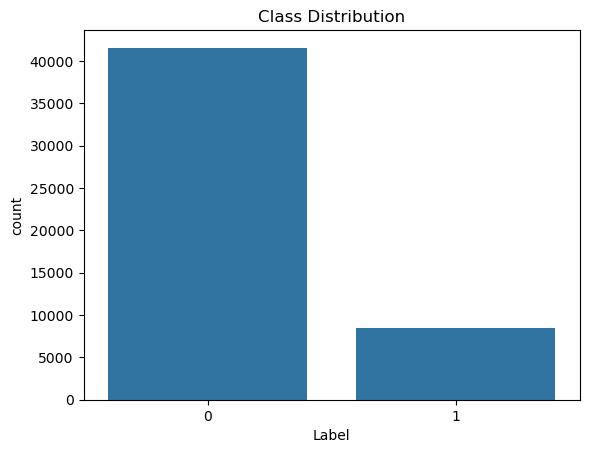

In [7]:
sns.countplot(x='Label', data=df)
plt.title("Class Distribution")
plt.show()

In [8]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,50000.000000,5.000000e+04,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,...,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000
mean,8608.498860,1.629148e+07,10.731620,12.161720,5.865136e+02,1.923739e+04,224.334180,19.469080,61.963875,74.695235,...,-1.651815e+03,9.053069e+04,4.557267e+04,1.698052e+05,6.403807e+04,9.089504e+06,5.125535e+05,9.478670e+06,8.682447e+06,0.168900
std,18915.878335,3.495487e+07,898.041077,1208.228074,6.352802e+03,2.632007e+06,728.973519,61.992304,187.859613,286.046682,...,3.751466e+05,6.412203e+05,4.027597e+05,1.050490e+06,5.394405e+05,2.456137e+07,4.621604e+06,2.526665e+07,2.431694e+07,0.374667
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,53.000000,2.070000e+02,2.000000,1.000000,1.200000e+01,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,80.000000,5.042700e+04,2.000000,2.000000,6.600000e+01,1.540000e+02,40.000000,2.000000,36.666667,0.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
75%,443.000000,5.259255e+06,5.000000,5.000000,3.270000e+02,8.720000e+02,201.000000,37.000000,52.000000,72.168411,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
max,65517.000000,1.200000e+08,199565.000000,268604.000000,1.177247e+06,5.850000e+08,23360.000000,1983.000000,3993.486486,5795.500690,...,5.600000e+01,4.252199e+07,2.570000e+07,5.901981e+07,2.602416e+07,1.200000e+08,7.060000e+07,1.200000e+08,1.200000e+08,1.000000


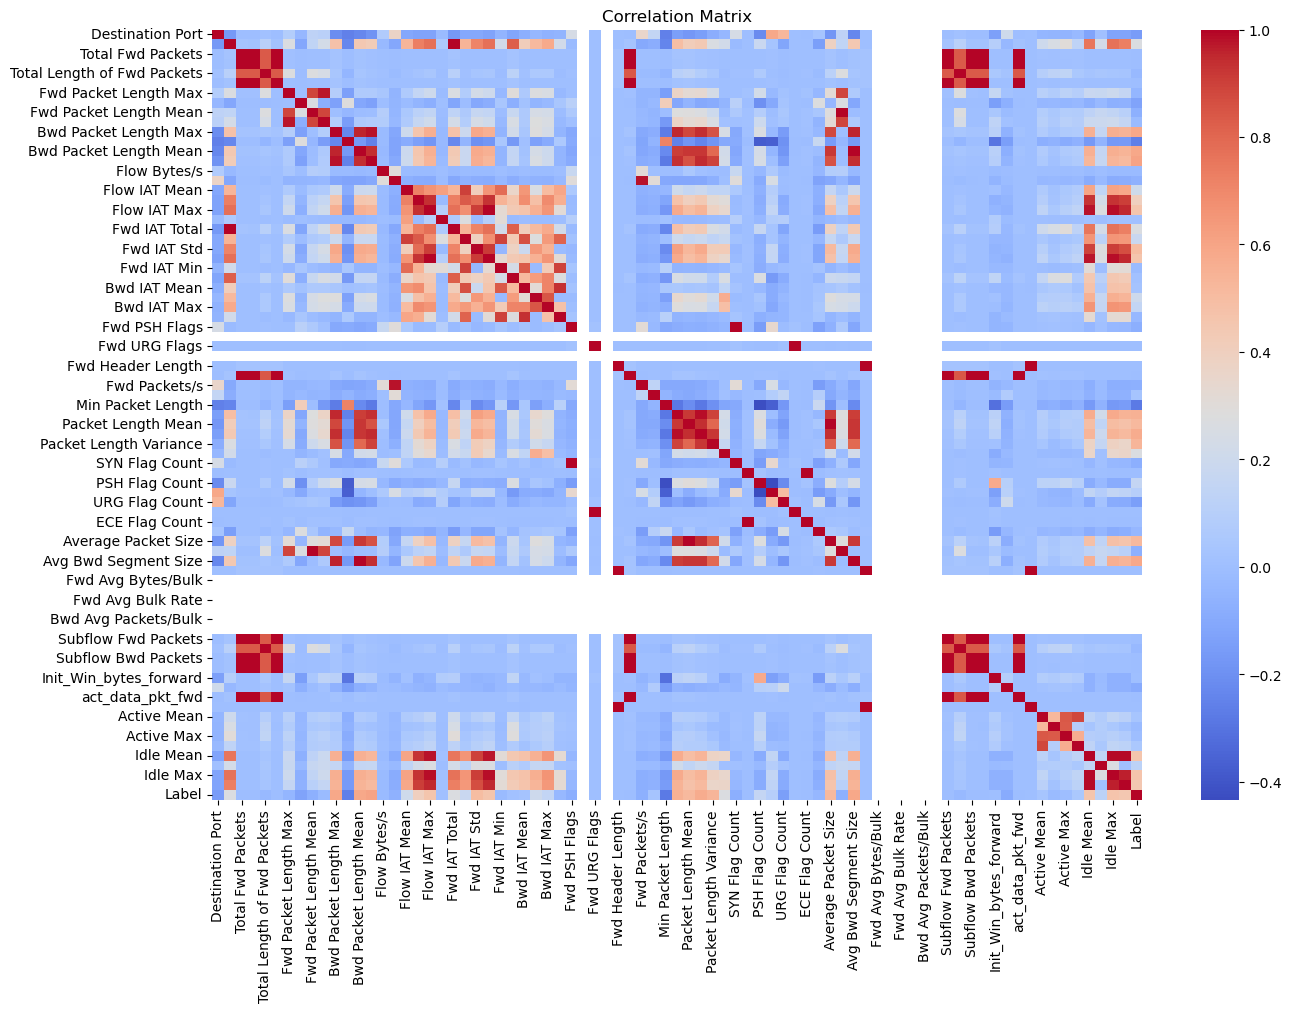

In [9]:
corr_matrix = df.corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
threshold = 0.9

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [column for column in upper.columns if any(upper[column] > threshold)]

print("Highly correlated features:", high_corr_features)

Highly correlated features: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Min', 'Bwd Header Length', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Idle Mean', 'Idle Max', 'Idle Min']


In [11]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold()

selector.fit(df.drop('Label', axis=1))

variances = selector.variances_

variance_df = pd.DataFrame({
    "Feature": df.drop('Label', axis=1).columns,
    "Variance": variances
})

variance_df.sort_values(by="Variance").head(10)

,Feature,Variance
31,Bwd PSH Flags,0.00000
58,Fwd Avg Bulk Rate,0.00000
59,Bwd Avg Bytes/Bulk,0.00000
60,Bwd Avg Packets/Bulk,0.00000
57,Fwd Avg Packets/Bulk,0.00000
56,Fwd Avg Bytes/Bulk,0.00000
61,Bwd Avg Bulk Rate,0.00000
33,Bwd URG Flags,0.00000
32,Fwd URG Flags,0.00002
49,CWE Flag Count,0.00002


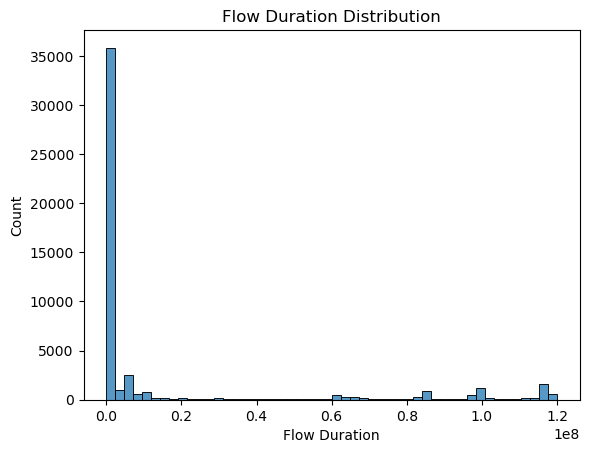

In [12]:
sns.histplot(df['Flow Duration'], bins=50)
plt.title("Flow Duration Distribution")
plt.show()